## Drones Montréal Cluster

#### I. Initialisation

In [14]:
import networkx as nx
import matplotlib.pyplot as plt
import itertools
from networkx.algorithms.matching import max_weight_matching
import random
import pickle

In [15]:
#Animation

import time
from IPython.display import clear_output

#### II. Graph

In [32]:
filename = "../database/maps/montreal.gpickle"

with open(filename, 'rb') as f:
    G = pickle.load(f).to_undirected()

KeyboardInterrupt: 

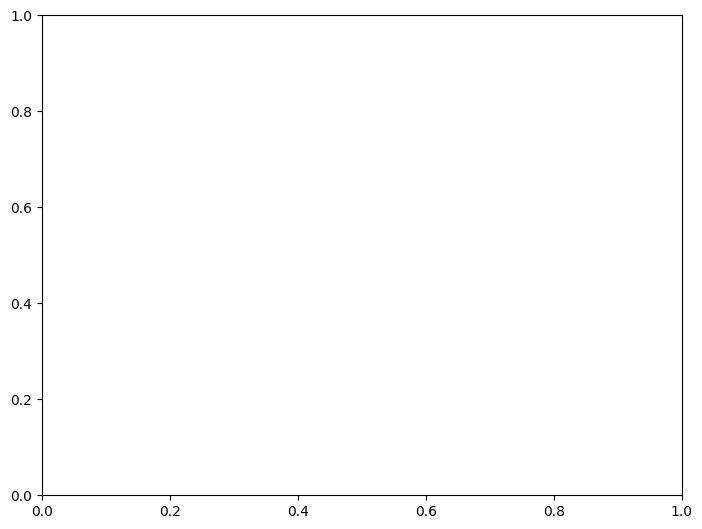

In [33]:
nx.draw(G)

In [35]:
import networkx as nx
import random
import itertools
import numpy as np
from sklearn.cluster import KMeans
from networkx.algorithms.matching import max_weight_matching

G_bis = nx.MultiGraph(G)

for u, v in G.edges():
    for key in G_bis[u][v]:
        G_bis[u][v][key]['snow'] = random.randint(0, 1)

odd_nodes = [v for v, d in G_bis.degree() if d % 2 == 1]

positions = np.array([[G.nodes[n]['x'], G.nodes[n]['y']] for n in odd_nodes])

k = 130  # nb de cluster
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(positions)

# Répartir les nœuds dans leurs clusters
clusters = {}
for idx, node in enumerate(odd_nodes):
    label = labels[idx]
    clusters.setdefault(label, []).append(node)

G_aug = nx.MultiGraph(G)

for label, nodes in clusters.items():
    if len(nodes) < 2:
        continue

    local_pairs = list(itertools.combinations(nodes, 2))

    pair_weights = {}
    for u, v in local_pairs:
        try:
            length = nx.dijkstra_path_length(G_bis, u, v, weight='length')
            pair_weights[(u, v)] = length
        except nx.NetworkXNoPath:
            continue

    neg_weights = {pair: -w for pair, w in pair_weights.items()}
    matching_graph = nx.Graph([(u, v, {'weight': neg_weights[(u, v)]}) for (u, v) in neg_weights])
    matching = max_weight_matching(matching_graph, maxcardinality=True)

    for u, v in matching:
        try:
            path = nx.dijkstra_path(G_bis, u, v, weight='length')
            path_edges = list(zip(path[:-1], path[1:]))
            for edge in path_edges:
                weight = G_bis[edge[0]][edge[1]][0]['length']
                G_aug.add_edge(edge[0], edge[1], weight=weight, virtual=True)
        except nx.NetworkXNoPath:
            continue

print("Ce graphe est eulérien :", nx.is_eulerian(G_aug))
if nx.is_eulerian(G_aug):
    circuit = list(nx.eulerian_circuit(G_aug))


Ce graphe est eulérien : False


In [36]:
# Étape de correction : traiter les sommets encore impairs globalement
remaining_odd_nodes = [v for v, d in G_aug.degree() if d % 2 == 1]
print(f"{len(remaining_odd_nodes)} sommets impairs restants après clustering")

if len(remaining_odd_nodes) > 1:
    residual_pairs = list(itertools.combinations(remaining_odd_nodes, 2))

    residual_weights = {}
    for u, v in residual_pairs:
        try:
            length = nx.dijkstra_path_length(G_bis, u, v, weight='length')
            residual_weights[(u, v)] = length
        except nx.NetworkXNoPath:
            continue

    neg_weights = {pair: -w for pair, w in residual_weights.items()}
    residual_graph = nx.Graph([(u, v, {'weight': neg_weights[(u, v)]}) for (u, v) in neg_weights])
    residual_matching = max_weight_matching(residual_graph, maxcardinality=True)

    for u, v in residual_matching:
        try:
            path = nx.dijkstra_path(G_bis, u, v, weight='length')
            path_edges = list(zip(path[:-1], path[1:]))
            for edge in path_edges:
                weight = G_bis[edge[0]][edge[1]][0]['length']
                G_aug.add_edge(edge[0], edge[1], weight=weight)
        except nx.NetworkXNoPath:
            continue


64 sommets impairs restants après clustering


In [37]:
print("Ce graphe est eulérien :", nx.is_eulerian(G_aug))


Ce graphe est eulérien : True


In [48]:
def snow_roads(G_aug, G_bis):
    circuit = list(nx.eulerian_circuit(G_aug))
    edges = []
    for i, (u, v) in enumerate(circuit):
        for key in G_bis[u][v]:
            if G_bis[u][v][key]['snow']:
                edges.append((u, v, key))

    return edges

snow_edges = snow_roads(G_aug, G_bis)
#print(snow_edges)


In [47]:
    pos = {node: (data['x'], data['y']) for node, data in G_aug.nodes(data=True)}
    cir = list(nx.eulerian_circuit(G_aug))
    
    def is_valid_edge(u, v, d):
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        return (x1 != x2) and (y1 != y2)

    edges_to_draw = [(u, v) for u, v, d in G_aug.edges(data=True) if is_valid_edge(u, v, d)]
    edges_drawn = []

    for i, edge in enumerate(cir):
        edges_drawn.append(edge)

        clear_output(wait=True)
        plt.figure(figsize=(20, 20))

        nx.draw_networkx_nodes(G_aug, pos, node_color="tab:blue", node_size=0, alpha=0.5)

        nx.draw_networkx_edges(G_aug, pos, edgelist=edges_to_draw, width=0.5, alpha=0.1, edge_color="gray")

        nx.draw_networkx_edges(G_aug, pos, edgelist=edges_drawn, width=2, alpha=0.9, edge_color="tab:red")

        nx.draw_networkx_edges(
        G_aug,
        pos,
        edgelist=snow_edges,
        width=1,
        alpha=0.5,
        edge_color="tab:blue",
    )

        plt.title(f"Montréal - Étape {i+1} / {len(cir)}", fontsize=14)
        plt.axis("off")
        plt.tight_layout()
        plt.show()
        

KeyboardInterrupt: 

### III. Comparaison

In [ ]:
def sum_dist(G):
    s = 0
    for u, v in G.edges():
        for key in G[u][v]:
            s += G[u][v][key]['length']
    return s

sum_dist(G)

In [ ]:
def sum_dist_circuit(G_bis, circuit):
    s = 0
    for i, (u, v) in enumerate(circuit):
        for key in G_bis[u][v]:
            if G_bis[u][v][key]['length']:
                s += G_bis[u][v][key]['length']
    km = s/1000
    cout = km/100
    print("Distance du circuit = " + str(round(km, 2)) + " km.")
    print("Cout du circuit = " + str(round(cout, 2)) + " €.")
    return s

sum_dist_circuit(G_bis, circuit)

#### Exporter

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import networkx as nx

pos = {node: (data['x'], data['y']) for node, data in G_aug.nodes(data=True)}
cir = list(nx.eulerian_circuit(G_aug))

def is_valid_edge(u, v, d):
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    return (x1 != x2) or (y1 != y2)

edges_to_draw = [(u, v) for u, v, d in G_aug.edges(data=True) if is_valid_edge(u, v, d)]

fig, ax = plt.subplots(figsize=(20, 20))
step = 4
frames = list(range(0, len(cir), step))
frames.append(len(cir) - 1)

def update(i):
    ax.clear()
    ax.set_title(f"Montréal – Étape {i+1} / {len(cir)}", fontsize=16)
    ax.axis("off")

    edges_drawn = cir[:i]

    nx.draw_networkx_nodes(G_aug, pos, node_color="tab:blue", node_size=1, alpha=0.5, ax=ax)

    nx.draw_networkx_edges(G_aug, pos, edgelist=edges_to_draw, width=0.5, alpha=0.1, edge_color="gray", ax=ax)

    nx.draw_networkx_edges(G_aug, pos, edgelist=snow_edges, width=1, alpha=0.5, edge_color="tab:blue", ax=ax)

    nx.draw_networkx_edges(G_aug, pos, edgelist=edges_drawn, width=2, alpha=0.9, edge_color="tab:red", ax=ax)

ani = animation.FuncAnimation(fig, update, frames=frames, interval=40)

# Export vidéo
ani.save("drone_montreal.mp4", writer='ffmpeg', fps=25)
plt.close()
